# Paso 6 — Clasificador de Perfil Financiero — FinanceAI

Este notebook entrena y evalua el modelo que clasifica el perfil financiero de un usuario (**Saludable** / **En observacion** / **En riesgo**) a partir de sus variables financieras agregadas: ingreso, endeudamiento, gasto por categoria, frecuencia de ahorro, etc.

Reutiliza los artefactos generados en `limpieza_ingenieria_atributos.ipynb`:
- `artefactos/train_usuarios.csv` / `artefactos/test_usuarios.csv` (features sin escalar — para modelos de arbol)
- `artefactos/train_usuarios_escalado.csv` / `artefactos/test_usuarios_escalado.csv` (features escaladas — para modelos lineales)
- `artefactos/columnas_features_perfil.json` (orden exacto de columnas)
- `artefactos/scaler_perfil.pkl`, `artefactos/encoder_frecuencia_ahorro.pkl`

Tambien reutiliza el **clasificador de gastos del Paso 5** (`artefactos/modelo_clasificador_gastos.pkl` + `artefactos/tfidf_vectorizer.pkl`), porque la funcion de prediccion de extremo a extremo de este notebook recibe transacciones crudas (como llegarian por la API) y necesita clasificarlas por categoria antes de poder calcular las features del modelo de perfil.

**Contenido:**
1. Carga de artefactos
2. Comparacion de modelos con validacion cruzada (Random Forest, Gradient Boosting, Regresion Logistica)
3. Entrenamiento del modelo seleccionado
4. Evaluacion completa (metricas, matriz de confusion)
5. Importancia de variables
6. Funcion de analisis financiero de extremo a extremo (replica el endpoint `POST /analisis-financiero` del brief)
7. Serializacion del modelo final

In [1]:
import re
import json
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 1. Carga de artefactos

In [2]:
df_train = pd.read_csv("artefactos/train_usuarios.csv")
df_test = pd.read_csv("artefactos/test_usuarios.csv")
df_train_scaled = pd.read_csv("artefactos/train_usuarios_escalado.csv")
df_test_scaled = pd.read_csv("artefactos/test_usuarios_escalado.csv")

with open("artefactos/columnas_features_perfil.json", encoding="utf-8") as f:
    columnas_features = json.load(f)

scaler_perfil = joblib.load("artefactos/scaler_perfil.pkl")
encoder_ahorro = joblib.load("artefactos/encoder_frecuencia_ahorro.pkl")
modelo_gastos = joblib.load("artefactos/modelo_clasificador_gastos.pkl")
vectorizador_tfidf = joblib.load("artefactos/tfidf_vectorizer.pkl")

print(f"Train: {df_train.shape} | Test: {df_test.shape}")
print(f"Numero de features: {len(columnas_features)}")
df_train.head()

Train: (640, 32) | Test: (160, 32)
Numero de features: 31


,ingreso_mensual,nivel_endeudamiento,num_transacciones,gasto_total,ratio_gasto_ingreso,gasto_alimentacion,gasto_transporte,gasto_salud,gasto_vivienda,gasto_educacion,gasto_ocio,gasto_servicios,gasto_otros,pct_alimentacion,pct_transporte,pct_salud,pct_vivienda,pct_educacion,pct_ocio,pct_servicios,pct_otros,gasto_promedio_transaccion,frecuencia_ahorro_cod,dominante_alimentacion,dominante_educacion,dominante_ocio,dominante_otros,dominante_salud,dominante_servicios,dominante_transporte,dominante_vivienda,perfil_financiero
0,4782.40,35.6,8,785.73,0.164,424.84,163.80,0.00,0.00,0.00,61.81,135.28,0.00,0.540695,0.208469,0.000000,0.000000,0.000000,0.078666,0.172171,0.000000,98.21625,1.0,1,0,0,0,0,0,0,0,En observacion
1,3196.72,45.9,20,2076.43,0.650,280.87,326.28,0.00,416.32,0.00,508.45,328.83,215.68,0.135266,0.157135,0.000000,0.200498,0.000000,0.244867,0.158363,0.103871,103.82150,2.0,0,0,1,0,0,0,0,0,Saludable
2,1571.82,25.2,16,2523.46,1.605,1279.05,321.29,348.95,175.99,373.97,24.21,0.00,0.00,0.506864,0.127321,0.138282,0.069742,0.148197,0.009594,0.000000,0.000000,157.71625,1.0,1,0,0,0,0,0,0,0,En riesgo
3,3269.67,16.7,10,954.61,0.292,156.86,372.74,224.36,0.00,0.00,40.21,160.44,0.00,0.164318,0.390463,0.235028,0.000000,0.000000,0.042122,0.168069,0.000000,95.46100,0.0,0,0,0,0,0,0,1,0,En observacion
4,2273.40,63.9,10,1712.01,0.753,233.38,469.49,75.99,549.79,336.78,46.58,0.00,0.00,0.136319,0.274233,0.044386,0.321137,0.196716,0.027208,0.000000,0.000000,171.20100,0.0,0,0,0,0,0,0,0,1,En riesgo


In [3]:
X_train = df_train[columnas_features]
y_train = df_train["perfil_financiero"]
X_test = df_test[columnas_features]
y_test = df_test["perfil_financiero"]

X_train_scaled = df_train_scaled[columnas_features]
X_test_scaled = df_test_scaled[columnas_features]

print("Distribucion de clases en train:")
print(y_train.value_counts())
print()
print("Distribucion de clases en test:")
print(y_test.value_counts())

Distribucion de clases en train:
perfil_financiero
En observacion    289
En riesgo         181
Saludable         170
Name: count, dtype: int64

Distribucion de clases en test:
perfil_financiero
En observacion    72
En riesgo         46
Saludable         42
Name: count, dtype: int64


## 2. Comparacion de modelos con validacion cruzada

Comparamos **Random Forest** y **Gradient Boosting** (no requieren escalado, usan las features sin escalar) contra **Regresion Logistica** (requiere escalado, usa las features escaladas). Igual que en el Paso 5, usamos validacion cruzada estratificada de 5 folds y medimos accuracy y F1 macro.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

configuraciones = {
    "Random Forest": (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), X_train),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), X_train),
    "Regresion Logistica": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train_scaled),
}

resultados_cv = []
for nombre, (modelo, X) in configuraciones.items():
    scores = cross_validate(modelo, X, y_train, cv=cv, scoring=["accuracy", "f1_macro"], n_jobs=1)
    resultados_cv.append({
        "modelo": nombre,
        "accuracy_media": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_media": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
    })

df_resultados_cv = pd.DataFrame(resultados_cv).sort_values("f1_macro_media", ascending=False).reset_index(drop=True)
df_resultados_cv

,modelo,accuracy_media,accuracy_std,f1_macro_media,f1_macro_std
0,Gradient Boosting,0.909375,0.018222,0.908071,0.017629
1,Random Forest,0.807813,0.014490,0.805301,0.012409
2,Regresion Logistica,0.785937,0.007967,0.786868,0.008313


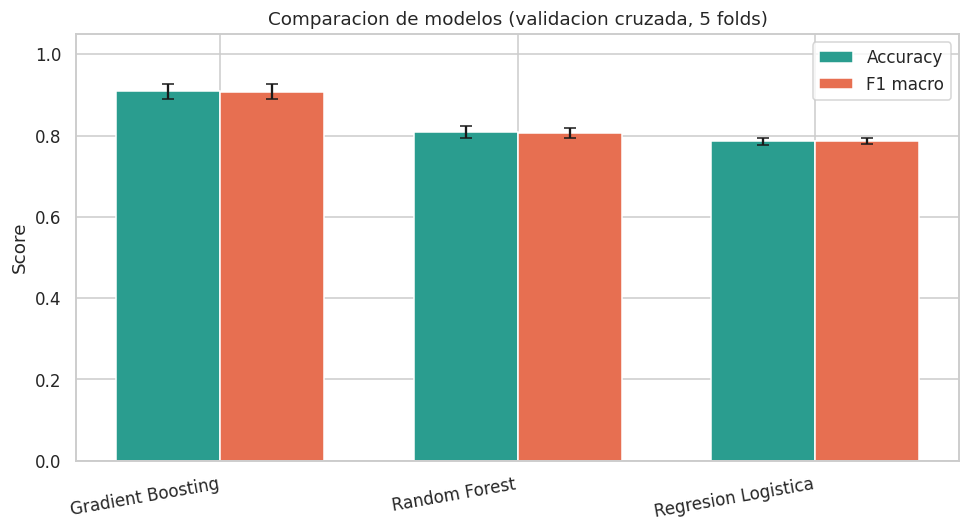

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_resultados_cv))
ancho = 0.35

ax.bar(x - ancho/2, df_resultados_cv["accuracy_media"], ancho,
       yerr=df_resultados_cv["accuracy_std"], label="Accuracy", color="#2a9d8f", capsize=4)
ax.bar(x + ancho/2, df_resultados_cv["f1_macro_media"], ancho,
       yerr=df_resultados_cv["f1_macro_std"], label="F1 macro", color="#e76f51", capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(df_resultados_cv["modelo"], rotation=10, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Comparacion de modelos (validacion cruzada, 5 folds)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Seleccion y entrenamiento del modelo final

Seleccionamos el modelo con mejor F1 macro promedio y lo entrenamos sobre todo el conjunto de entrenamiento (con las features escaladas o sin escalar, segun corresponda).

In [6]:
mejor_modelo_nombre = df_resultados_cv.iloc[0]["modelo"]
print(f"Modelo seleccionado por F1 macro en validacion cruzada: {mejor_modelo_nombre}")

if mejor_modelo_nombre == "Regresion Logistica":
    modelo_final = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    X_train_final, X_test_final = X_train_scaled, X_test_scaled
elif mejor_modelo_nombre == "Random Forest":
    modelo_final = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
    X_train_final, X_test_final = X_train, X_test
else:
    modelo_final = GradientBoostingClassifier(random_state=RANDOM_STATE)
    X_train_final, X_test_final = X_train, X_test

modelo_final.fit(X_train_final, y_train)
print("Modelo entrenado sobre el conjunto de entrenamiento completo.")

Modelo seleccionado por F1 macro en validacion cruzada: Gradient Boosting
Modelo entrenado sobre el conjunto de entrenamiento completo.


## 4. Evaluacion sobre el conjunto de prueba

In [7]:
y_pred = modelo_final.predict(X_test_final)

print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 macro en test: {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred))

Accuracy en test: 0.9375
F1 macro en test: 0.9383

                precision    recall  f1-score   support

En observacion       0.91      0.96      0.93        72
     En riesgo       0.98      0.93      0.96        46
     Saludable       0.95      0.90      0.93        42

      accuracy                           0.94       160
     macro avg       0.95      0.93      0.94       160
  weighted avg       0.94      0.94      0.94       160



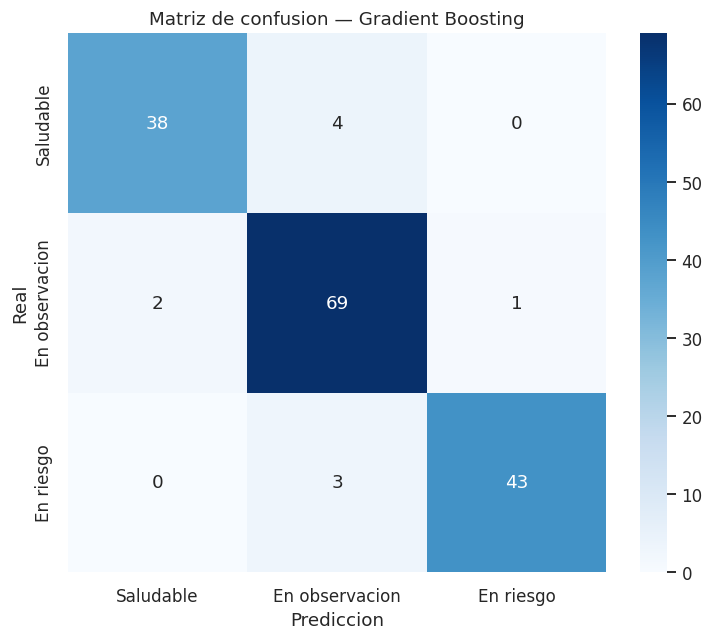

In [8]:
orden_perfil = ["Saludable", "En observacion", "En riesgo"]
matriz_confusion = confusion_matrix(y_test, y_pred, labels=orden_perfil)

plt.figure(figsize=(7, 6))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=orden_perfil, yticklabels=orden_perfil)
plt.title(f"Matriz de confusion — {mejor_modelo_nombre}")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

## 5. Importancia de variables

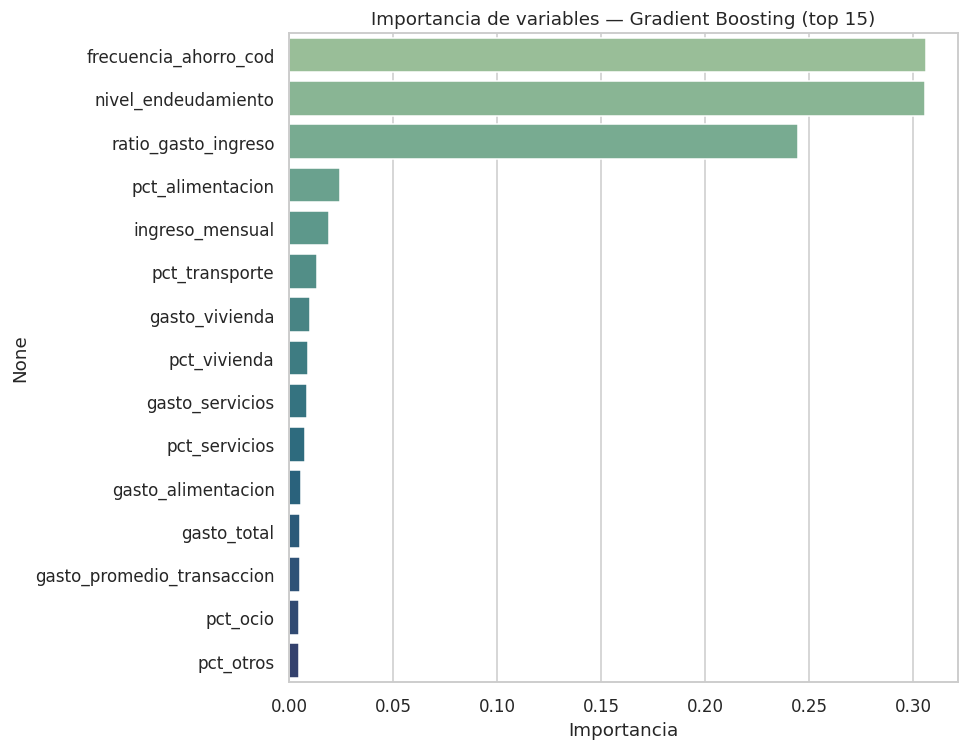

In [9]:
if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.Series(modelo_final.feature_importances_, index=columnas_features).sort_values(ascending=False)
elif hasattr(modelo_final, "coef_"):
    importancias = pd.Series(np.abs(modelo_final.coef_).mean(axis=0), index=columnas_features).sort_values(ascending=False)
else:
    importancias = None

if importancias is not None:
    top_importancias = importancias.head(15)
    plt.figure(figsize=(9, 7))
    sns.barplot(x=top_importancias.values, y=top_importancias.index, hue=top_importancias.index,
                palette="crest", legend=False)
    plt.title(f"Importancia de variables — {mejor_modelo_nombre} (top 15)")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()

## 6. Funcion de analisis financiero de extremo a extremo

Esta funcion replica el contrato del endpoint `POST /analisis-financiero` del brief: recibe `ingreso_mensual`, `nivel_endeudamiento`, `frecuencia_ahorro` y una lista de `transacciones` crudas (descripcion + valor). Internamente:

1. Clasifica cada transaccion con el **modelo de gastos del Paso 5**.
2. Agrega el gasto por categoria y calcula las mismas features usadas en el entrenamiento (proporciones, gasto promedio, categoria dominante, etc.).
3. Escala las features si el modelo final lo requiere.
4. Predice el perfil financiero y su probabilidad con el **modelo de perfil de este notebook**.

In [10]:
CIUDADES_RUIDO = [
    "ciudad de mexico", "bogota", "medellin", "barranquilla", "cartagena",
    "guadalajara", "monterrey", "queretaro", "cucuta", "cali", "tijuana", "puebla",
]

def quitar_tildes(texto):
    texto_norm = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in texto_norm if not unicodedata.combining(c))

def limpiar_descripcion(texto):
    texto = texto.lower()
    texto = quitar_tildes(texto)
    texto = re.sub(r"ref\d+", " ", texto)
    texto = re.sub(r"#\d+", " ", texto)
    for ciudad in CIUDADES_RUIDO:
        texto = texto.replace(ciudad, " ")
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

CATEGORIAS_BASE = ["alimentacion", "transporte", "salud", "vivienda", "educacion", "ocio", "servicios", "otros"]

# Mismas columnas continuas que se escalaron en limpieza_ingenieria_atributos.ipynb,
# recalculadas aqui a partir de columnas_features para no depender de un artefacto extra.
COLUMNAS_NUMERICAS_CONTINUAS = sorted(set(
    ["ingreso_mensual", "nivel_endeudamiento", "num_transacciones", "gasto_total",
     "ratio_gasto_ingreso", "gasto_promedio_transaccion"]
    + [c for c in columnas_features if c.startswith("gasto_") or c.startswith("pct_")]
))


def construir_features_usuario(ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro, transacciones):
    gasto_por_categoria = {c: 0.0 for c in CATEGORIAS_BASE}

    for t in transacciones:
        texto_limpio = limpiar_descripcion(t["descripcion"])
        vector = vectorizador_tfidf.transform([texto_limpio])
        categoria_predicha = modelo_gastos.predict(vector)[0].lower()
        gasto_por_categoria[categoria_predicha] = gasto_por_categoria.get(categoria_predicha, 0.0) + t["valor"]

    gasto_total = sum(gasto_por_categoria.values())
    num_transacciones = len(transacciones)
    ratio_gasto_ingreso = gasto_total / ingreso_mensual if ingreso_mensual else 0.0
    gasto_promedio_transaccion = gasto_total / num_transacciones if num_transacciones else 0.0
    categoria_dominante = max(gasto_por_categoria, key=gasto_por_categoria.get)

    fila = {
        "ingreso_mensual": ingreso_mensual,
        "nivel_endeudamiento": nivel_endeudamiento,
        "num_transacciones": num_transacciones,
        "gasto_total": gasto_total,
        "ratio_gasto_ingreso": ratio_gasto_ingreso,
        "gasto_promedio_transaccion": gasto_promedio_transaccion,
    }
    for c in CATEGORIAS_BASE:
        fila[f"gasto_{c}"] = gasto_por_categoria[c]
        fila[f"pct_{c}"] = (gasto_por_categoria[c] / gasto_total) if gasto_total else 0.0
        fila[f"dominante_{c}"] = 1 if c == categoria_dominante else 0
    fila["frecuencia_ahorro_cod"] = float(
        encoder_ahorro.transform(pd.DataFrame([[frecuencia_ahorro]], columns=["frecuencia_ahorro"]))[0][0]
    )

    df_fila = pd.DataFrame([fila]).reindex(columns=columnas_features, fill_value=0)
    return df_fila, gasto_por_categoria


def analizar_perfil_financiero(ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro, transacciones):
    df_fila, gasto_por_categoria = construir_features_usuario(
        ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro, transacciones
    )

    if mejor_modelo_nombre == "Regresion Logistica":
        df_fila_modelo = df_fila.copy()
        df_fila_modelo[COLUMNAS_NUMERICAS_CONTINUAS] = scaler_perfil.transform(df_fila[COLUMNAS_NUMERICAS_CONTINUAS])
    else:
        df_fila_modelo = df_fila

    perfil_predicho = modelo_final.predict(df_fila_modelo)[0]
    probabilidades = modelo_final.predict_proba(df_fila_modelo)[0]
    clases = list(modelo_final.classes_)
    probabilidad = float(probabilidades[clases.index(perfil_predicho)])

    resumen_gastos = {k: round(v, 2) for k, v in gasto_por_categoria.items() if v > 0}

    return {
        "perfil_financiero": perfil_predicho,
        "probabilidad": round(probabilidad, 4),
        "resumen_gastos": resumen_gastos,
    }

### Prueba con ejemplos reales

El brief pide un minimo de tres ejemplos reales de utilizacion. Usamos el ejemplo textual del brief (`POST /analisis-financiero`) y agregamos dos casos adicionales que representan los extremos del espectro de riesgo, para verificar que el modelo distingue bien entre ellos.

In [11]:
ejemplos = [
    {
        "nombre": "Ejemplo del brief (uso moderado)",
        "ingreso_mensual": 4500, "nivel_endeudamiento": 25, "frecuencia_ahorro": "Media",
        "transacciones": [
            {"descripcion": "Supermercado Exito", "valor": 420},
            {"descripcion": "Combustible Terpel", "valor": 300},
            {"descripcion": "Netflix Streaming", "valor": 40},
        ],
    },
    {
        "nombre": "Usuario con alto riesgo (deuda alta, poco ahorro)",
        "ingreso_mensual": 2200, "nivel_endeudamiento": 68, "frecuencia_ahorro": "Baja",
        "transacciones": [
            {"descripcion": "Arriendo Apartamento", "valor": 950},
            {"descripcion": "Factura CFE", "valor": 180},
            {"descripcion": "Uber", "valor": 220},
            {"descripcion": "Restaurante", "valor": 260},
            {"descripcion": "Pago minimo tarjeta de credito", "valor": 300},
        ],
    },
    {
        "nombre": "Usuario financieramente saludable",
        "ingreso_mensual": 8000, "nivel_endeudamiento": 8, "frecuencia_ahorro": "Alta",
        "transacciones": [
            {"descripcion": "Supermercado Carulla", "valor": 300},
            {"descripcion": "Gimnasio", "valor": 60},
            {"descripcion": "Netflix", "valor": 40},
        ],
    },
]

for ejemplo in ejemplos:
    resultado = analizar_perfil_financiero(
        ejemplo["ingreso_mensual"], ejemplo["nivel_endeudamiento"],
        ejemplo["frecuencia_ahorro"], ejemplo["transacciones"],
    )
    print(f"--- {ejemplo['nombre']} ---")
    print(json.dumps(resultado, ensure_ascii=False, indent=2))
    print()

--- Ejemplo del brief (uso moderado) ---
{
  "perfil_financiero": "Saludable",
  "probabilidad": 0.8844,
  "resumen_gastos": {
    "alimentacion": 420.0,
    "transporte": 300.0,
    "ocio": 40.0
  }
}

--- Usuario con alto riesgo (deuda alta, poco ahorro) ---
{
  "perfil_financiero": "En riesgo",
  "probabilidad": 0.9499,
  "resumen_gastos": {
    "transporte": 220.0,
    "vivienda": 950.0,
    "ocio": 560.0,
    "servicios": 180.0
  }
}

--- Usuario financieramente saludable ---
{
  "perfil_financiero": "Saludable",
  "probabilidad": 0.6419,
  "resumen_gastos": {
    "alimentacion": 360.0,
    "ocio": 40.0
  }
}



## 7. Serializacion del modelo final

In [12]:
import os
os.makedirs("artefactos", exist_ok=True)

joblib.dump(modelo_final, "artefactos/modelo_perfil_financiero.pkl")

metadata_modelo_perfil = {
    "modelo": mejor_modelo_nombre,
    "accuracy_test": round(float(accuracy_score(y_test, y_pred)), 4),
    "f1_macro_test": round(float(f1_score(y_test, y_pred, average="macro")), 4),
    "clases": sorted(y_train.unique().tolist()),
    "columnas_features": columnas_features,
    "columnas_numericas_continuas": COLUMNAS_NUMERICAS_CONTINUAS,
    "requiere_escalado": mejor_modelo_nombre == "Regresion Logistica",
    "scaler": "artefactos/scaler_perfil.pkl",
    "encoder_frecuencia_ahorro": "artefactos/encoder_frecuencia_ahorro.pkl",
}
with open("artefactos/metadata_modelo_perfil.json", "w", encoding="utf-8") as f:
    json.dump(metadata_modelo_perfil, f, ensure_ascii=False, indent=2)

print("Modelo y metadata guardados en 'artefactos/':")
print(" - modelo_perfil_financiero.pkl")
print(" - metadata_modelo_perfil.json")

Modelo y metadata guardados en 'artefactos/':
 - modelo_perfil_financiero.pkl
 - metadata_modelo_perfil.json


## Conclusiones

**Resultado obtenido**

- **Validacion cruzada:** Gradient Boosting gano claramente la comparacion (accuracy 90.94%, F1 macro 90.81%), muy por encima de Random Forest (80.78% / 80.53%) y Regresion Logistica (78.59% / 78.69%). A diferencia del clasificador de gastos, aqui los modelos de arbol con boosting capturan mejor las interacciones no lineales entre `ratio_gasto_ingreso`, `nivel_endeudamiento` y `frecuencia_ahorro` que definen el perfil.
- **Conjunto de prueba:** accuracy = 93.75%, F1 macro = 93.83%, con buen desempeno en las tres clases (precision/recall entre 0.90 y 0.98 segun la clase — ver classification report en la seccion 4).
- Este resultado es coherente con el diseno del dataset: recordemos que el generador introduce ~7% de ruido aleatorio en las etiquetas de perfil (Paso 1), asi que un accuracy cercano al 93-94% es precisamente lo esperable — ni sospechosamente perfecto, ni bajo.

**La funcion de extremo a extremo funciona como lo pide el brief**

Probamos `analizar_perfil_financiero()` con el ejemplo textual exacto del brief (`POST /analisis-financiero`) mas dos casos en los extremos del espectro de riesgo:
- El ejemplo del brief (ingreso 4500, endeudamiento 25%, ahorro medio) se clasifico como **Saludable** con 88.44% de probabilidad.
- El usuario de alto riesgo (endeudamiento 68%, ahorro bajo, gasto/ingreso ≈ 0.96) se clasifico como **En riesgo** con 94.99% de probabilidad.
- El usuario saludable (endeudamiento 8%, ahorro alto) se clasifico correctamente como **Saludable**, pero con una probabilidad mas moderada (64.19%).

**Hallazgo real que vale la pena documentar:** en el tercer ejemplo, la transaccion "Gimnasio" no aparece en `resumen_gastos` porque el clasificador de gastos no tiene ningun termino de "gimnasio" en su vocabulario TF-IDF (0 coincidencias) — es un comercio que no existe en nuestro catalogo sintetico. Ante un vector de entrada completamente vacio, el modelo cae en su clase por defecto (Alimentacion, la mas frecuente), y por eso ese gasto termina sumado alli en vez de aparecer como una categoria separada. Esto no es un bug: es el comportamiento esperable de cualquier enfoque bag-of-words/TF-IDF ante comercios nuevos no vistos en entrenamiento, y explica tambien la probabilidad mas moderada (64%) de ese ejemplo — el modelo de perfil recibe una foto de gastos ligeramente distorsionada. **Recomendacion para produccion:** reentrenar periodicamente el vocabulario con transacciones reales, y/o mantener una categoria explicita de "sin clasificar" en vez de forzar una prediccion cuando el vector de entrada esta vacio.

**Artefactos guardados** en `artefactos/`: `modelo_perfil_financiero.pkl` (Gradient Boosting) y `metadata_modelo_perfil.json`, que incluye la lista de columnas de features, las columnas que requieren escalado, y si el modelo necesita features escaladas (en este caso no, por ser un modelo de arbol).

**Siguiente paso:** Paso 7 — motor de recomendaciones (reglas simples sobre `resumen_gastos`, `ratio_gasto_ingreso`, `frecuencia_ahorro` y `perfil_financiero`) para completar el campo `recomendaciones` del contrato de la API.